In [1]:
#   KLASIFIKASI LOAN APPROVAL MENGGUNAKAN ANN (Artificial Neural Network)
#   Dataset  : Loan Approval Classification Dataset - Kaggle
#   Link     : kaggle.com/datasets/taweilo/loan-approval-classification-data

# Import library
import numpy as np    # Untuk operasi matematika dan matriks
import pandas as pd   # Untuk membaca dan mengolah data tabel
import matplotlib.pyplot as plt # Untuk membuat grafik dan visualisasi
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Untuk split data, normalisasi, dan evaluasi model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("✅ Import selesai!")

✅ Import selesai!


In [3]:
# Upload dan load data
df = pd.read_csv('loan_data.csv')
print(f"✅ Dataset dimuat: {df.shape[0]:,} baris, {df.shape[1]} kolom")
df.head()

✅ Dataset dimuat: 45,000 baris, 14 kolom


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

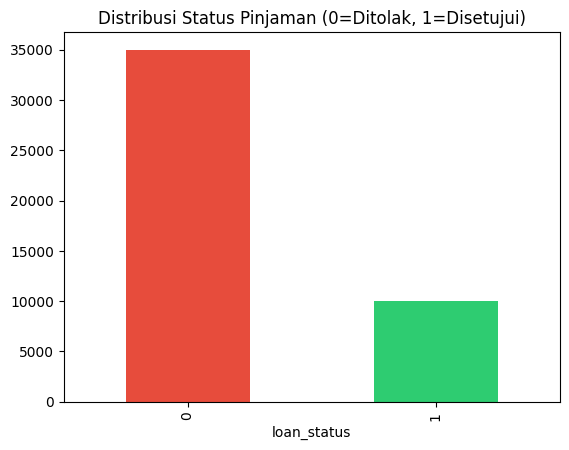

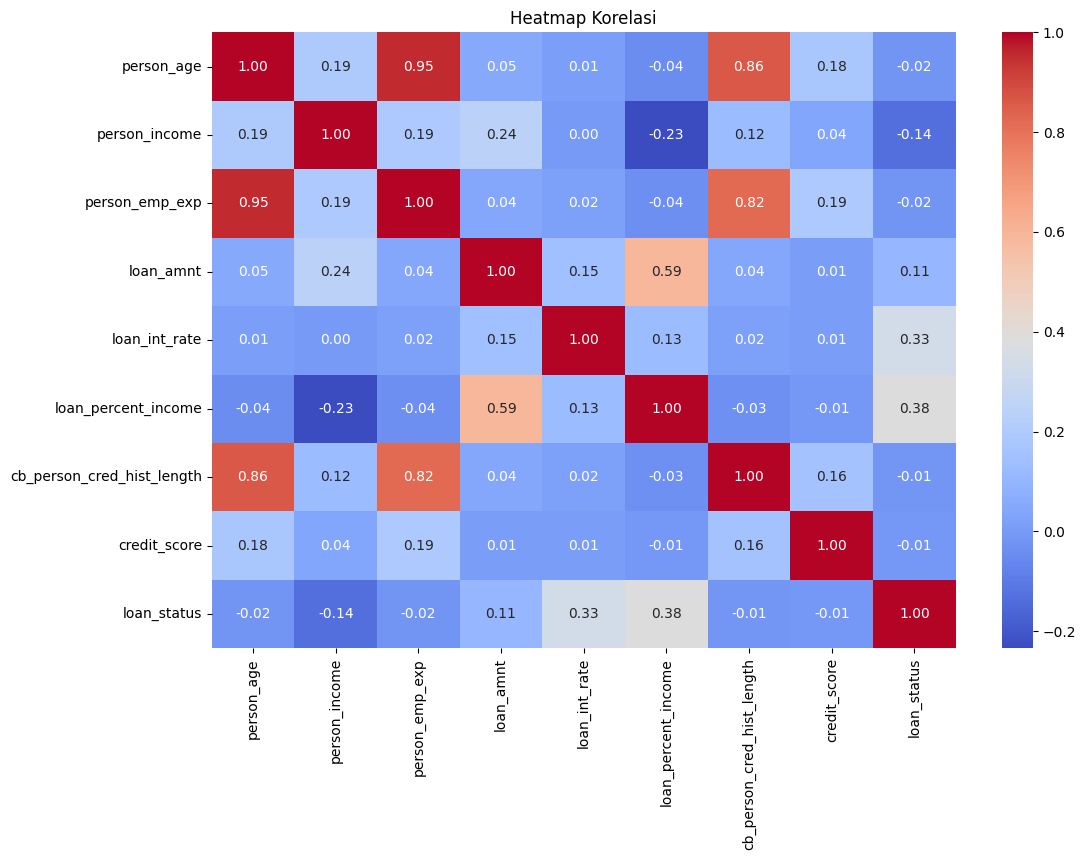

In [4]:
# EDA (Eksplorasi Data)
print(df.info())
print("\nMissing value:\n", df.isnull().sum())
print("\nDistribusi target:\n", df['loan_status'].value_counts())

# Visualisasi distribusi target
df['loan_status'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Distribusi Status Pinjaman (0=Ditolak, 1=Disetujui)')
plt.show()

# Heatmap korelasi
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

In [5]:
# Preprocessing
df_clean = df.copy()

# Encode kolom teks (angka)
le = LabelEncoder()
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = le.fit_transform(df_clean[col])

# Pisahkan fitur (X) dan target (y)
X = df_clean.drop('loan_status', axis=1).values
y = df_clean['loan_status'].values.reshape(1, -1)  # shape: (1, jumlah_data)

# Split 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y.T, test_size=0.2, random_state=42, stratify=y.T
)

# Normalisasi data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Transpose agar bentuknya (fitur, sampel), format yang dipakai ANN from scratch
X_train = X_train.T   # shape: (13, n_train)
X_test  = X_test.T    # shape: (13, n_test)
y_train = y_train.T   # shape: (1, n_train)
y_test  = y_test.T    # shape: (1, n_test)

print(f"✅ X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"✅ y_train: {y_train.shape} | y_test: {y_test.shape}")

✅ X_train: (13, 36000) | X_test: (13, 9000)
✅ y_train: (1, 36000) | y_test: (1, 9000)


In [6]:
# Fungsi" ANN from scratch
# A. Inisialisasi Parameter
def initialize_parameters(input_size, hidden_size, output_size):
    np.random.seed(42)
    parameters = {
        "W1": np.random.randn(hidden_size, input_size) * 0.01,   # bobot hidden layer
        "b1": np.zeros((hidden_size, 1)),                        # bias hidden layer
        "W2": np.random.randn(output_size, hidden_size) * 0.01,  # bobot output layer
        "b2": np.zeros((output_size, 1))                         # bias output layer
    }
    return parameters

# B. Fungsi Aktivasi
def sigmoid(Z):
    # Mengubah nilai menjadi probabilitas antara 0 dan 1
    return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

def relu(Z):
    # Jika nilai positif → tetap, jika negatif → jadi 0
    return np.maximum(0, Z)

def relu_derivative(Z):
    # Turunan ReLU untuk backpropagation
    return (Z > 0).astype(float)

# C. Forward Propagation
def forward_propagation(X, parameters):
    W1, b1 = parameters["W1"], parameters["b1"]
    W2, b2 = parameters["W2"], parameters["b2"]

    Z1 = np.dot(W1, X) + b1      # hitung input hidden layer
    A1 = relu(Z1)                # aktifkan dengan ReLU
    Z2 = np.dot(W2, A1) + b2     # hitung input output layer
    A2 = sigmoid(Z2)             # aktifkan dengan Sigmoid : probabilitas

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

# D. Compute Cost (Binary Cross-Entropy)
def compute_cost(Y, A2):
    m = Y.shape[1]
    # Binary Cross-Entropy Loss
    cost = -np.sum(Y * np.log(A2 + 1e-8) + (1 - Y) * np.log(1 - A2 + 1e-8)) / m
    return float(np.squeeze(cost))

# E. Backpropagation (Hitung Gradien)
def backward_propagation(X, Y, parameters, cache):
    m = X.shape[1]
    W2 = parameters["W2"]

    dZ2 = cache["A2"] - Y                           # error di output layer
    dW2 = np.dot(dZ2, cache["A1"].T) / m            # gradien W2
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m    # gradien b2

    dZ1 = np.dot(W2.T, dZ2) * relu_derivative(cache["Z1"])   # error di hidden layer
    dW1 = np.dot(dZ1, X.T) / m                               # gradien W1
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m             # gradien b1

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

# F. Update Parameter (Gradient Descent)
def update_parameters(parameters, grads, learning_rate):
    for key in parameters:
        parameters[key] -= learning_rate * grads["d" + key]
    return parameters

# G. Prediksi
def predict(X, parameters):
    A2, _ = forward_propagation(X, parameters)
    return (A2 > 0.5).astype(int)

print("✅ Semua fungsi ANN berhasil didefinisikan!")

✅ Semua fungsi ANN berhasil didefinisikan!


In [7]:
# Training model ANN from scratch
input_size  = X_train.shape[0]    # 13 fitur
hidden_size = 16                  # 16 neuron di hidden layer
output_size = 1                   # 1 output (disetujui/ditolak)
epochs      = 1000                # jumlah iterasi training
learning_rate = 0.01              # kecepatan belajar model

# Inisialisasi parameter
parameters = initialize_parameters(input_size, hidden_size, output_size)

# Simpan history cost untuk visualisasi
cost_history = []

print("🚀 Mulai training ANN from scratch...\n")

for i in range(epochs):
    # Forward propagation
    A2, cache = forward_propagation(X_train, parameters)

    # Hitung cost
    cost = compute_cost(y_train, A2)
    cost_history.append(cost)

    # Backpropagation
    grads = backward_propagation(X_train, y_train, parameters, cache)

    # Update bobot
    parameters = update_parameters(parameters, grads, learning_rate)

    # Tampilkan progress setiap 100 epoch
    if i % 100 == 0:
        y_pred_train = predict(X_train, parameters).flatten()
        acc = accuracy_score(y_train.flatten(), y_pred_train) * 100
        print(f"  Epoch {i:4d} | Loss: {cost:.4f} | Akurasi Training: {acc:.2f}%")

print("\n✅ Training selesai!")

🚀 Mulai training ANN from scratch...

  Epoch    0 | Loss: 0.6934 | Akurasi Training: 74.91%
  Epoch  100 | Loss: 0.6323 | Akurasi Training: 77.78%
  Epoch  200 | Loss: 0.5950 | Akurasi Training: 77.78%
  Epoch  300 | Loss: 0.5718 | Akurasi Training: 77.78%
  Epoch  400 | Loss: 0.5571 | Akurasi Training: 77.78%
  Epoch  500 | Loss: 0.5475 | Akurasi Training: 77.78%
  Epoch  600 | Loss: 0.5410 | Akurasi Training: 77.78%
  Epoch  700 | Loss: 0.5363 | Akurasi Training: 77.78%
  Epoch  800 | Loss: 0.5327 | Akurasi Training: 77.78%
  Epoch  900 | Loss: 0.5295 | Akurasi Training: 77.78%

✅ Training selesai!


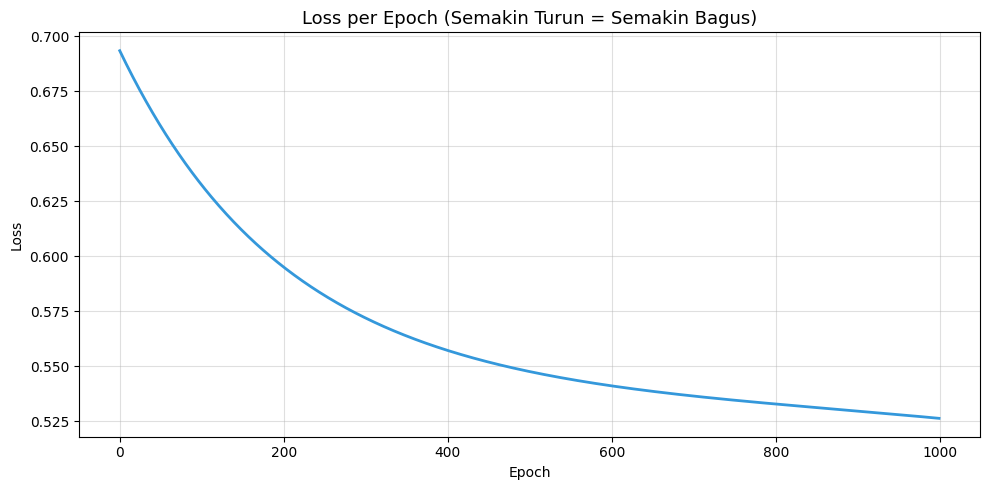

In [8]:
# Visualisasi training
plt.figure(figsize=(10, 5))
plt.plot(cost_history, color='#3498db', linewidth=2)
plt.title('Loss per Epoch (Semakin Turun = Semakin Bagus)', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

📊 EVALUASI MODEL
Akurasi: 77.78%

              precision    recall  f1-score   support

     Ditolak       0.78      1.00      0.88      7000
   Disetujui       0.00      0.00      0.00      2000

    accuracy                           0.78      9000
   macro avg       0.39      0.50      0.44      9000
weighted avg       0.60      0.78      0.68      9000



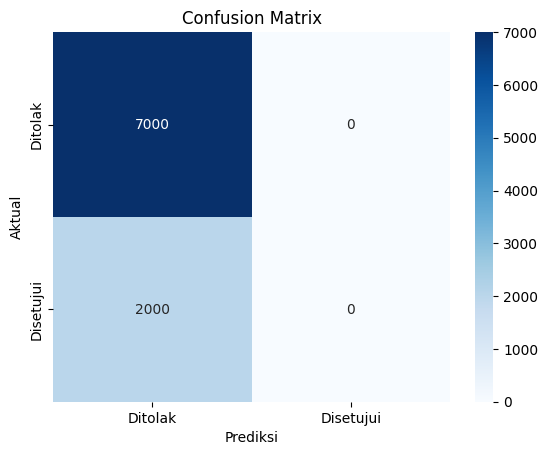

In [9]:
# Evaluasi model
y_pred = predict(X_test, parameters).flatten()
y_true = y_test.flatten()

print("=" * 50)
print("📊 EVALUASI MODEL")
print("=" * 50)
print(f"Akurasi: {accuracy_score(y_true, y_pred)*100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=['Ditolak', 'Disetujui']))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ditolak', 'Disetujui'],
            yticklabels=['Ditolak', 'Disetujui'])
plt.title('Confusion Matrix')
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.show()

In [10]:
# Prediksi data baru
data_baru = pd.DataFrame([{
    'person_age': 30, 'person_gender': 1, 'person_education': 2,
    'person_income': 65000, 'person_emp_exp': 5, 'person_home_ownership': 1,
    'loan_amnt': 10000, 'loan_intent': 3, 'loan_int_rate': 11.5,
    'loan_percent_income': 0.15, 'cb_person_cred_hist_length': 4,
    'credit_score': 650, 'previous_loan_defaults_on_file': 0
}])

data_baru_scaled = scaler.transform(data_baru).T  # transpose jadi (13, 1)
prob   = forward_propagation(data_baru_scaled, parameters)[0][0][0]
status = "✅ DISETUJUI" if prob >= 0.5 else "❌ DITOLAK"

print(f"Probabilitas Disetujui : {prob*100:.1f}%")
print(f"Hasil Prediksi         : {status}")

Probabilitas Disetujui : 25.7%
Hasil Prediksi         : ❌ DITOLAK
